# Evaluation

## Objectif

L'objectif de cette évaluation est de parvenir à détecter si une requête est une tentative d'intrusion ou bien une requête légitime.

Votre modèle devrait obtenir un score de 95%.

## Livrable

Vous devrez compléter ce notebook Jupyter et répondre aux questions du Google Form associé [EPSI - PARIS - 2026 - TRDE707 - TP Noté](https://forms.gle/ZhcULFdgYDDm4P7Q9).

## Dépendances et modules

Les modules disponibles pour l'exécution de ce notebook sont :
* pandas
* scikit-learn
* matplotlib

## Source de données

Les sources de données sont des fichiers au format CSV. Vous pouvez les télécharger depuis le dossier [trde707-datasets](https://drive.google.com/drive/folders/1YmNxtXDhiyzoyH6R6twWudgdjUAYvsNo?usp=sharing).

L'archive public_network_log.zip contient un unique fichier public_network_log.csv qui représente un log de requêtes identifiées comme une tentative d'intrusion ou une requête légitime.

L'archive dbip-country-lite-2026-01.zip contient un unique fichier dbip-country-lite-2026-01.csv qui associe à chaque plage d'IP un code Pays. Cette base de données est issue du portail [dbip](https://db-ip.com/db/format/ip-to-country/csv.html).


Charger les données


In [5]:
#!pip install pandas
import pandas as pd
pd = pd.read_csv('public_network_logs.csv')

In [4]:
pd.info()

<class 'pandas.DataFrame'>
RangeIndex: 7076 entries, 0 to 7075
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Source_IP       7076 non-null   str  
 1   Destination_IP  7076 non-null   str  
 2   Port            7076 non-null   int64
 3   Request_Type    7076 non-null   str  
 4   Protocol        7076 non-null   str  
 5   Payload_Size    7076 non-null   int64
 6   User_Agent      7076 non-null   str  
 7   Status          7076 non-null   str  
 8   Intrusion       7076 non-null   int64
 9   Scan_Type       7076 non-null   str  
dtypes: int64(3), str(7)
memory usage: 552.9 KB


In [6]:
pd.head()

,Source_IP,Destination_IP,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Intrusion,Scan_Type
0,216.181.134.4,14.249.18.128,23,SSH,ICMP,1758,python-requests/2.25.1,Failure,1,BotAttack
1,205.176.120.255,1.248.189.118,4444,HTTP,ICMP,156,curl/7.68.0,Failure,1,PortScan
2,94.40.34.8,178.236.92.228,31337,SSH,TCP,47,python-requests/2.25.1,Failure,1,PortScan
3,190.68.147.22,55.30.40.29,23,HTTP,TCP,113,nmap/7.80,Failure,1,PortScan
4,33.5.52.172,205.64.170.115,31337,HTTPS,UDP,1676,nmap/7.80,Failure,1,BotAttack


Afficher les effectifs de la colonne `Intrusion`.


In [8]:
print(pd['Intrusion'].value_counts())

Intrusion
0    6400
1     676
Name: count, dtype: int64


Afficher les 2 représentations les plus adaptées à la colonne `Payload_Size`.


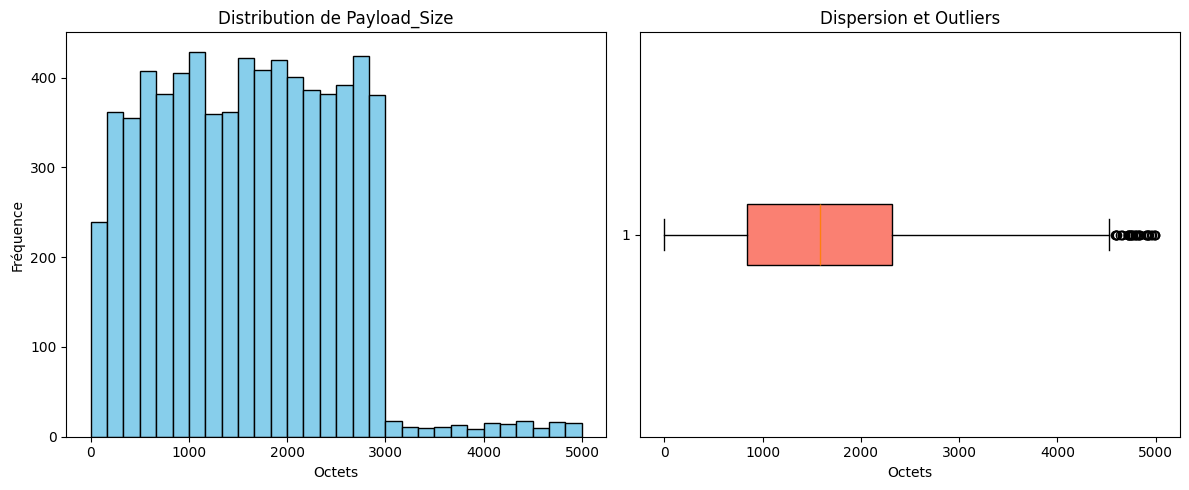

In [14]:
#!pip install matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
# 1. Histogramme avec Matplotlib
plt.subplot(1, 2, 1)
plt.hist(pd['Payload_Size'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution de Payload_Size')
plt.xlabel('Octets')
plt.ylabel('Fréquence')

# 2. Boîte à moustaches (Boxplot) avec Matplotlib
plt.subplot(1, 2, 2)
plt.boxplot(pd['Payload_Size'], vert=False, patch_artist=True, 
            boxprops=dict(facecolor='salmon'))
plt.title('Dispersion et Outliers')
plt.xlabel('Octets')

plt.tight_layout()
plt.show()

Afficher la représentation la plus adaptée à `Port`.


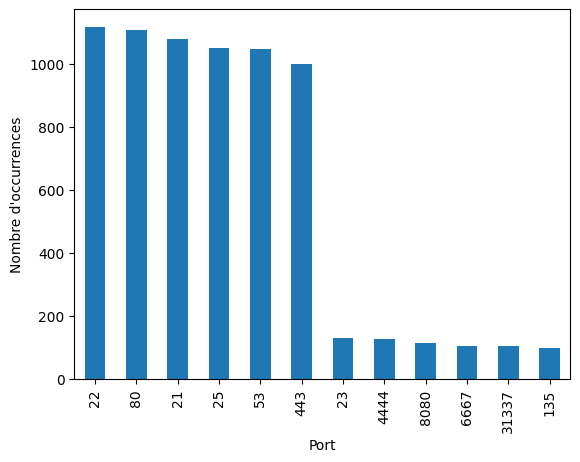

In [17]:
pd['Port'].value_counts().plot(kind='bar')
plt.xlabel("Port")
plt.ylabel("Nombre d'occurrences")
plt.show()

Afficher sur un même graphique les variables `Payload_Size`, `Port` et `Intrusion`.


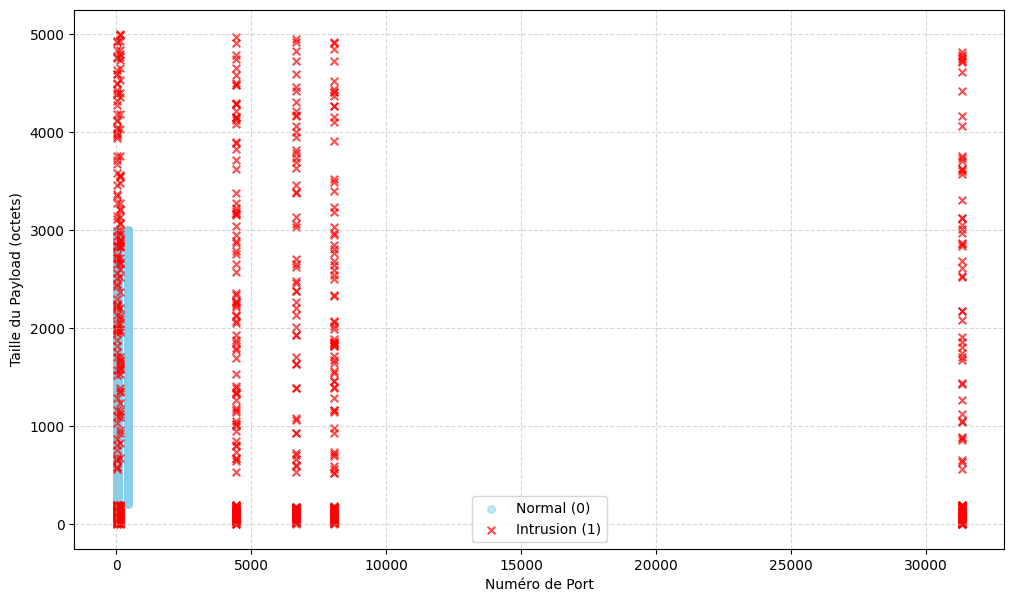

In [19]:
normal = pd[pd['Intrusion'] == 0]
intrusion = pd[pd['Intrusion'] == 1]
plt.figure(figsize=(12, 7))
plt.scatter(normal['Port'], normal['Payload_Size'], 
            c='skyblue', label='Normal (0)', alpha=0.5, s=30)

# Tracer les points d'intrusion (rouges, plus visibles)
plt.scatter(intrusion['Port'], intrusion['Payload_Size'], 
            c='red', label='Intrusion (1)', alpha=0.7, s=30, marker='x')

plt.xlabel('Numéro de Port')
plt.ylabel('Taille du Payload (octets)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Sélectionner les colonnes pour lesquelles un encodage est nécessaire.


In [20]:
colonnes_a_encoder = pd.select_dtypes(include=['object', 'category']).columns

print("Colonnes à encoder :", list(colonnes_a_encoder))

Colonnes à encoder : ['Source_IP', 'Destination_IP', 'Request_Type', 'Protocol', 'User_Agent', 'Status', 'Scan_Type']


C:\Users\frank\AppData\Local\Temp\ipykernel_34048\1150927107.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_a_encoder = pd.select_dtypes(include=['object', 'category']).columns


Sélectionner les colonnes pour lesquelles une standardisation est nécessaire.


In [ ]:
# Sélection des colonnes numériques
colonnes_numeriques = pd.select_dtypes(include=['int64', 'float64']).columns

# Colonnes à exclure de la standardisation
colonnes_a_exclure = ['Port', 'Intrusion']

colonnes_a_standardiser = [
    col for col in colonnes_numeriques
    if col not in colonnes_a_exclure
]

print("Colonnes à standardiser :", colonnes_a_standardiser)


Colonnes à standardiser : ['Payload_Size']


Sélectionner un modèle et l'entrainer.

In [35]:
#modele sélectionné: Random Forest Classifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

#nettoyage des données
data = pd.drop(['Source_IP', 'Destination_IP'], axis=1)
#encodage des variables catégorielles
le = LabelEncoder()
categorical_cols = ['Request_Type', 'Protocol', 'User_Agent', 'Status', 'Scan_Type']

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])
#séparation des caractéristiques et de la cible
X = data.drop('Intrusion', axis=1)
y = data['Intrusion']
#division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#création et entraînement du modèle
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train) 



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Evaluer les performances de votre modèle.

In [36]:
#evaluation du modèle
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1267
           1       1.00      1.00      1.00       149

    accuracy                           1.00      1416
   macro avg       1.00      1.00      1.00      1416
weighted avg       1.00      1.00      1.00      1416



In [37]:
print(f"Précision globale : {accuracy_score(y_test, y_pred):.2%}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Précision globale : 100.00%

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1267
           1       1.00      1.00      1.00       149

    accuracy                           1.00      1416
   macro avg       1.00      1.00      1.00      1416
weighted avg       1.00      1.00      1.00      1416



Choisir un affichage permettant de restituer les performances du modèle sélectionné.

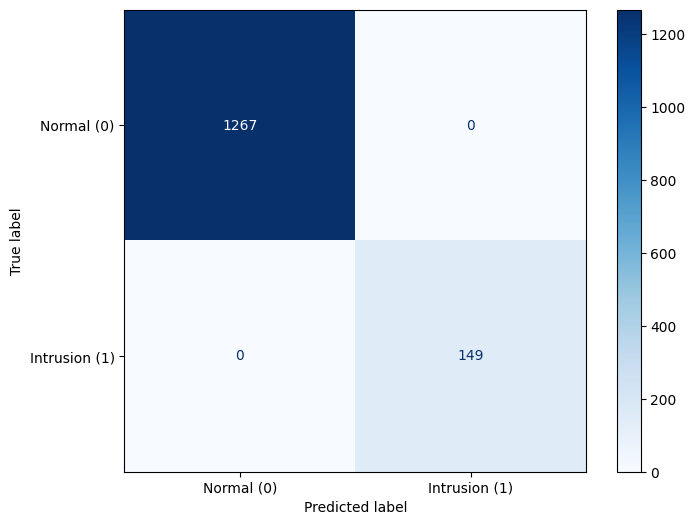

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#calcule de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

#création de la figure et des axes
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Intrusion (1)'])


disp.plot(cmap='Blues', ax=ax)
plt.grid(False) 
plt.show()